# 02 · Exploratory Data Analysis

**Questions**
1. How did the business grow, and which months are complete enough to analyse?
2. What sells, and what drives revenue?
3. How do customers pay?
4. Where are customers and sellers located?
5. When do people shop?

In [1]:
import sys
import warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))   # make the project package importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import olist_analysis as oa

oa.set_style()
warnings.filterwarnings("ignore", category=DeprecationWarning)   # library-version noise, not relevant to results
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
df = oa.load_order_table()
print(f"{len(df):,} orders from {df['order_purchase_timestamp'].min():%d %b %Y} to {df['order_purchase_timestamp'].max():%d %b %Y}")

99,441 orders from 04 Sep 2016 to 17 Oct 2018


## 1 · Growth over time

In [3]:
monthly = (
    df.groupby("purchase_month")
      .agg(orders=("order_id", "count"), revenue=("payment_value", "sum"))
)
monthly.style.format({"orders": "{:,.0f}", "revenue": "R$ {:,.0f}"})

,orders,revenue
purchase_month,,
2016-09-01 00:00:00,4,R$ 252
2016-10-01 00:00:00,324,"R$ 59,090"
2016-12-01 00:00:00,1,R$ 20
2017-01-01 00:00:00,800,"R$ 138,488"
2017-02-01 00:00:00,"1,780","R$ 291,908"
2017-03-01 00:00:00,"2,682","R$ 449,864"
2017-04-01 00:00:00,"2,404","R$ 417,788"
2017-05-01 00:00:00,"3,700","R$ 592,919"
2017-06-01 00:00:00,"3,245","R$ 511,276"


The first months (Sep-Dec 2016) and the final months (Sep-Oct 2018) contain only a handful of orders - the platform was launching
and the extract was cut mid-stream. **Analysis window: January 2017 - August 2018** (20 complete months).

Orders in window: 99,092 (99.6% of all orders)


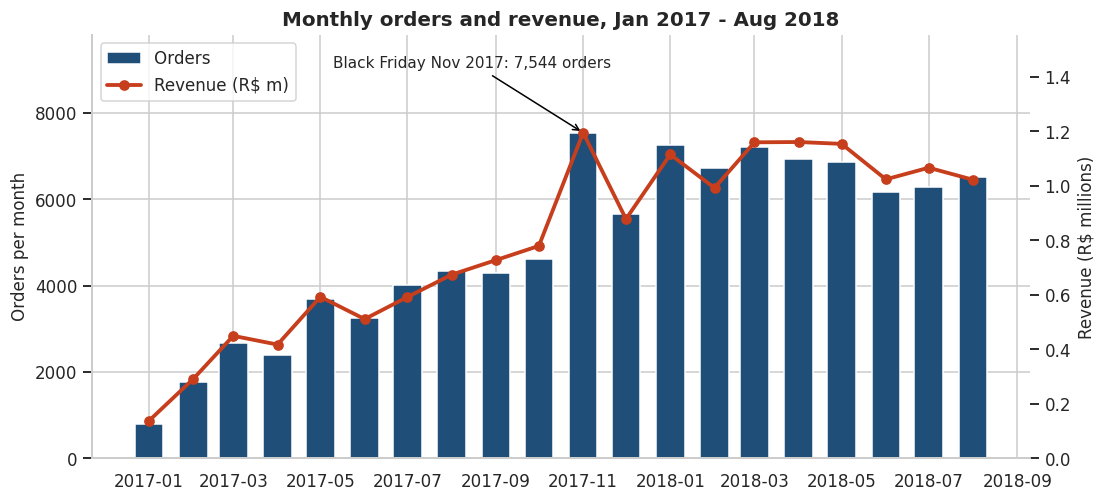

Jan-Aug 2018 vs Jan-Aug 2017 orders: +135%


In [4]:
WINDOW = (pd.Timestamp("2017-01-01"), pd.Timestamp("2018-08-31 23:59:59"))
dfw = df[df["order_purchase_timestamp"].between(*WINDOW)].copy()
m = monthly.loc["2017-01-01":"2018-08-01"]
print(f"Orders in window: {len(dfw):,} ({len(dfw) / len(df):.1%} of all orders)")

fig, ax1 = plt.subplots(figsize=(11, 5))
bars = ax1.bar(m.index, m["orders"], width=20, color=oa.BASE, label="Orders")
ax1.set_ylabel("Orders per month")
ax1.set_ylim(0, m["orders"].max() * 1.3)
ax2 = ax1.twinx()
line, = ax2.plot(m.index, m["revenue"] / 1e6, color=oa.ACCENT, marker="o", lw=2.5, label="Revenue (R$ m)")
ax2.set_ylabel("Revenue (R$ millions)")
ax2.set_ylim(0, m["revenue"].max() / 1e6 * 1.3)
ax2.grid(False)
peak = m["orders"].idxmax()
ax1.annotate(f"Black Friday {peak:%b %Y}: {m.loc[peak, 'orders']:,} orders",
             xy=(peak, m.loc[peak, "orders"]), xytext=(pd.Timestamp("2017-05-10"), m["orders"].max() * 1.2),
             arrowprops=dict(arrowstyle="->", color="black"), fontsize=10)
ax1.set_title("Monthly orders and revenue, Jan 2017 - Aug 2018")
ax1.legend(handles=[bars, line], loc="upper left", frameon=True)
oa.save(fig, "02_monthly_growth")
plt.show()

h1_17 = m.loc["2017-01-01":"2017-08-01", "orders"].sum()
h1_18 = m.loc["2018-01-01":"2018-08-01", "orders"].sum()
print(f"Jan-Aug 2018 vs Jan-Aug 2017 orders: {h1_18 / h1_17 - 1:+.0%}")

## 2 · What sells

In [5]:
raw = oa.load_raw()   # item level, so every item is credited to its own category
prod = oa.data.english_products(raw["products"], raw["category_translation"])
it = raw["items"].merge(prod[["product_id", "category"]], on="product_id")
it = it[it["order_id"].isin(dfw["order_id"])]

cat = (it.groupby("category")
         .agg(revenue=("price", "sum"), items=("order_item_id", "count"), avg_price=("price", "mean"))
         .sort_values("revenue", ascending=False))
cat["revenue_share"] = cat["revenue"] / cat["revenue"].sum()
cat["cumulative_share"] = cat["revenue_share"].cumsum()
n80 = int((cat["cumulative_share"] < 0.80).sum() + 1)
print(f"{len(cat)} categories; the top {n80} generate 80% of item revenue (Pareto).")
cat.head(10)

74 categories; the top 18 generate 80% of item revenue (Pareto).


,revenue,items,avg_price,revenue_share,cumulative_share
category,,,,,
health beauty,"1,253,993.86",9619,130.37,0.09,0.09
watches gifts,"1,201,645.44",5986,200.74,0.09,0.18
bed bath table,"1,036,509.69",11107,93.32,0.08,0.26
sports leisure,"984,715.33",8622,114.21,0.07,0.33
computers accessories,"910,555.00",7806,116.65,0.07,0.40
furniture decor,"723,881.71",8265,87.58,0.05,0.45
cool stuff,"634,179.85",3788,167.42,0.05,0.50
housewares,"630,961.59",6952,90.76,0.05,0.54
auto,"590,886.86",4223,139.92,0.04,0.59


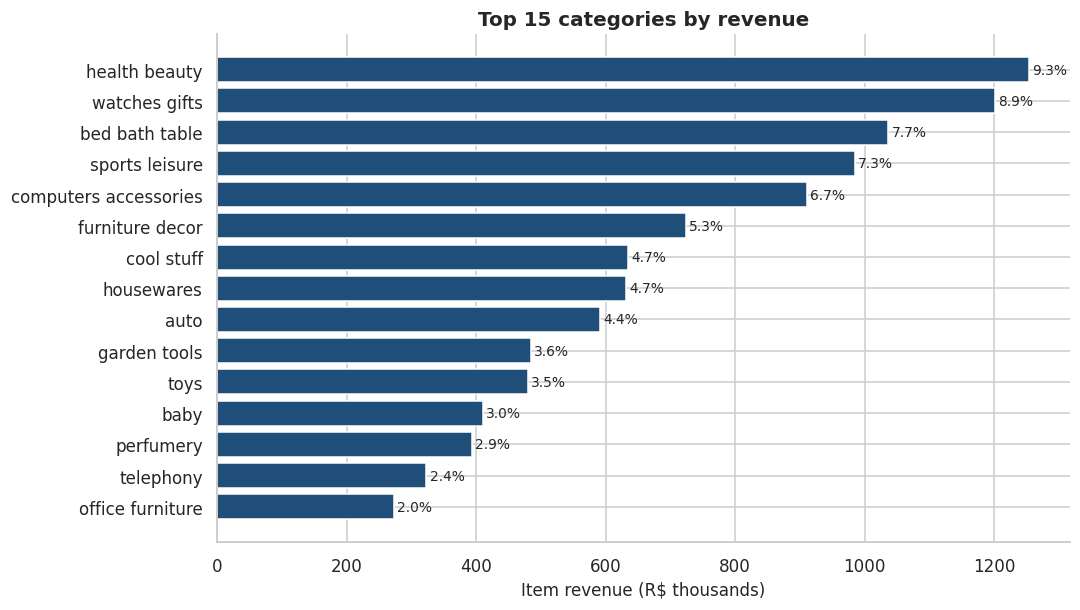

In [6]:
top = cat.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top.index, top["revenue"] / 1e3, color=oa.BASE)
ax.invert_yaxis()
ax.set_xlabel("Item revenue (R$ thousands)")
ax.set_title("Top 15 categories by revenue")
for y, (rev, share) in enumerate(zip(top["revenue"] / 1e3, top["revenue_share"])):
    ax.text(rev + 5, y, f"{share:.1%}", va="center", fontsize=9)
oa.save(fig, "02_top_categories")
plt.show()

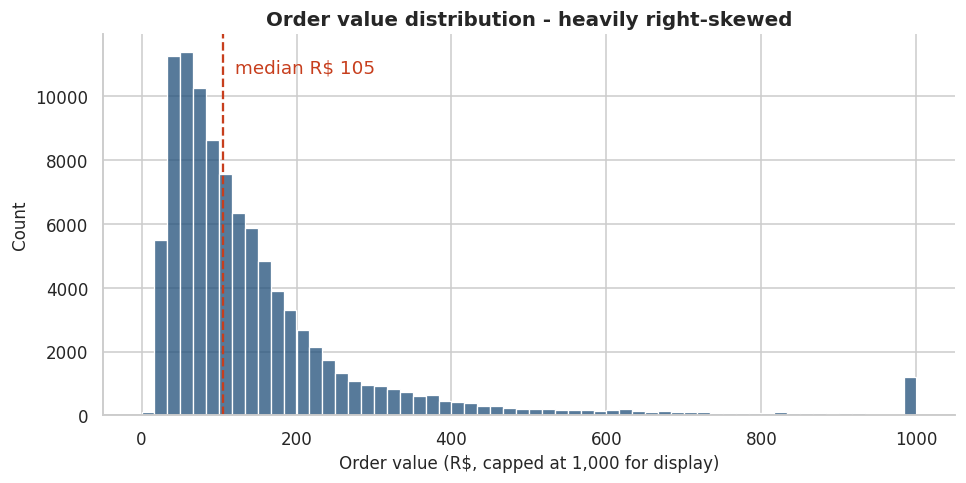

count   99,092.00
mean       160.91
std        221.93
min          0.00
50%        105.28
90%        307.90
99%      1,075.75
max     13,664.08
Name: payment_value, dtype: float64

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.histplot(dfw["payment_value"].clip(upper=1000), bins=60, color=oa.BASE, ax=ax)
med = dfw["payment_value"].median()
ax.axvline(med, color=oa.ACCENT, ls="--")
ax.text(med + 15, ax.get_ylim()[1] * 0.9, f"median R$ {med:,.0f}", color=oa.ACCENT)
ax.set_xlabel("Order value (R$, capped at 1,000 for display)")
ax.set_title("Order value distribution - heavily right-skewed")
oa.save(fig, "02_order_value_distribution")
plt.show()
dfw["payment_value"].describe(percentiles=[.5, .9, .99])

## 3 · How customers pay

In [8]:
pay = (dfw.groupby("payment_type")
          .agg(orders=("order_id", "count"), avg_value=("payment_value", "mean"), avg_installments=("max_installments", "mean"))
          .sort_values("orders", ascending=False))
pay["share"] = pay["orders"] / pay["orders"].sum()
pay

,orders,avg_value,avg_installments,share
payment_type,,,,
credit_card,74721,167.21,3.55,0.75
boleto,19721,145.01,1.00,0.20
voucher,3123,119.45,1.15,0.03
debit_card,1525,142.75,1.00,0.02
not_defined,2,0.00,1.00,0.00


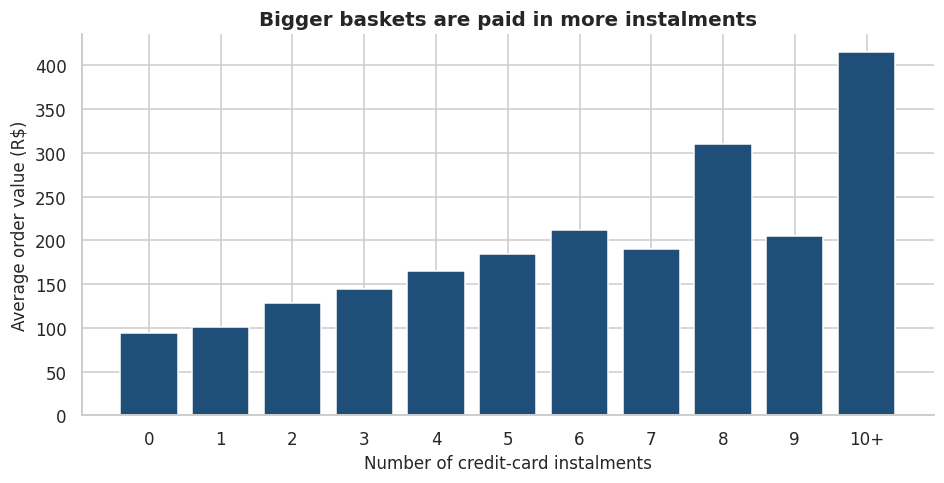

In [9]:
cc = dfw[dfw["payment_type"] == "credit_card"]
inst = cc.groupby(cc["max_installments"].clip(upper=10))["payment_value"].agg(["count", "mean"])
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(inst.index.astype(int).astype(str).str.replace("10", "10+"), inst["mean"], color=oa.BASE)
ax.set_xlabel("Number of credit-card instalments")
ax.set_ylabel("Average order value (R$)")
ax.set_title("Bigger baskets are paid in more instalments")
oa.save(fig, "02_installments")
plt.show()

In Brazil, splitting purchases into *parcelas* (instalments) is common - average order value rises steadily with the number of instalments.

## 4 · Where customers and sellers are

In [10]:
geo = pd.DataFrame({
    "customers_share": dfw["customer_state"].value_counts(normalize=True),
    "sellers_share": dfw.drop_duplicates("main_seller_id")["seller_state"].value_counts(normalize=True),
}).fillna(0).sort_values("customers_share", ascending=False)
geo.head(10).style.format("{:.1%}")

,customers_share,sellers_share
SP,42.0%,59.8%
RJ,12.9%,5.5%
MG,11.7%,7.9%
RS,5.5%,4.1%
PR,5.1%,11.3%
SC,3.7%,6.2%
BA,3.4%,0.6%
DF,2.2%,1.0%
ES,2.0%,0.8%
GO,2.0%,1.3%


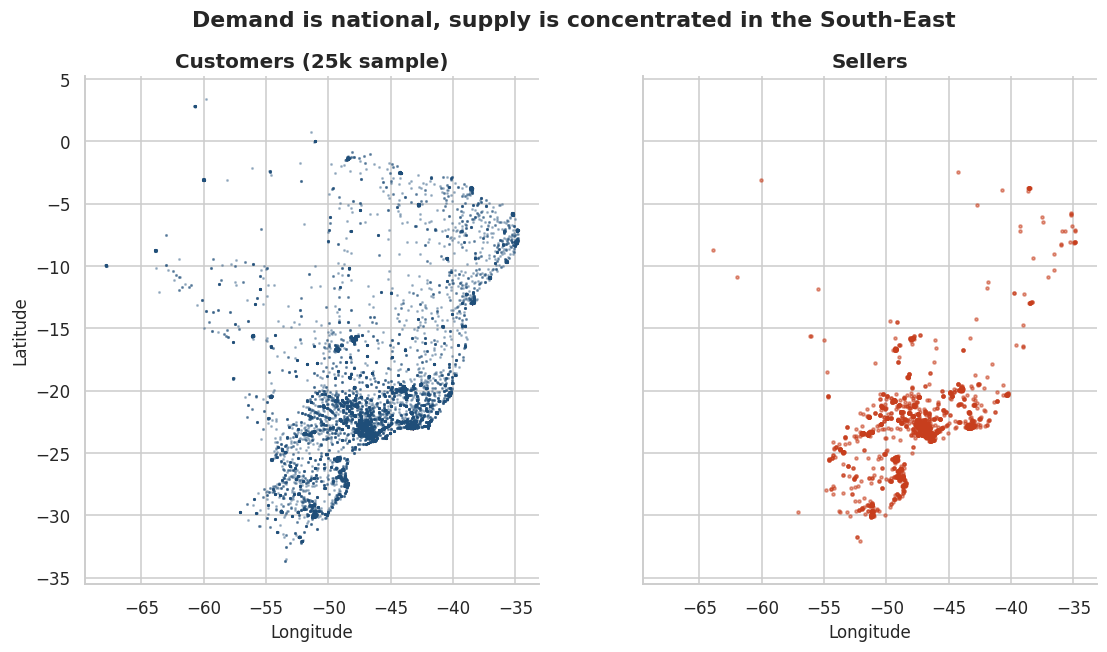

Orders whose main seller is in SP: 70.4%
Orders shipped across state lines: 64.3%


In [11]:
pts = dfw.dropna(subset=["customer_lat"]).sample(25_000, random_state=42)
sellers = dfw.dropna(subset=["seller_lat"]).drop_duplicates("main_seller_id")

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
axes[0].scatter(pts["customer_lng"], pts["customer_lat"], s=1, alpha=0.3, color=oa.BASE)
axes[0].set_title("Customers (25k sample)")
axes[1].scatter(sellers["seller_lng"], sellers["seller_lat"], s=4, alpha=0.5, color=oa.ACCENT)
axes[1].set_title("Sellers")
for ax in axes:
    ax.set_aspect("equal"); ax.set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.suptitle("Demand is national, supply is concentrated in the South-East", fontweight="bold")
oa.save(fig, "02_customer_seller_map")
plt.show()

print(f"Orders whose main seller is in SP: {dfw['seller_state'].eq('SP').mean():.1%}")
print(f"Orders shipped across state lines: {(~dfw['same_state']).mean():.1%}")

## 5 · When people shop

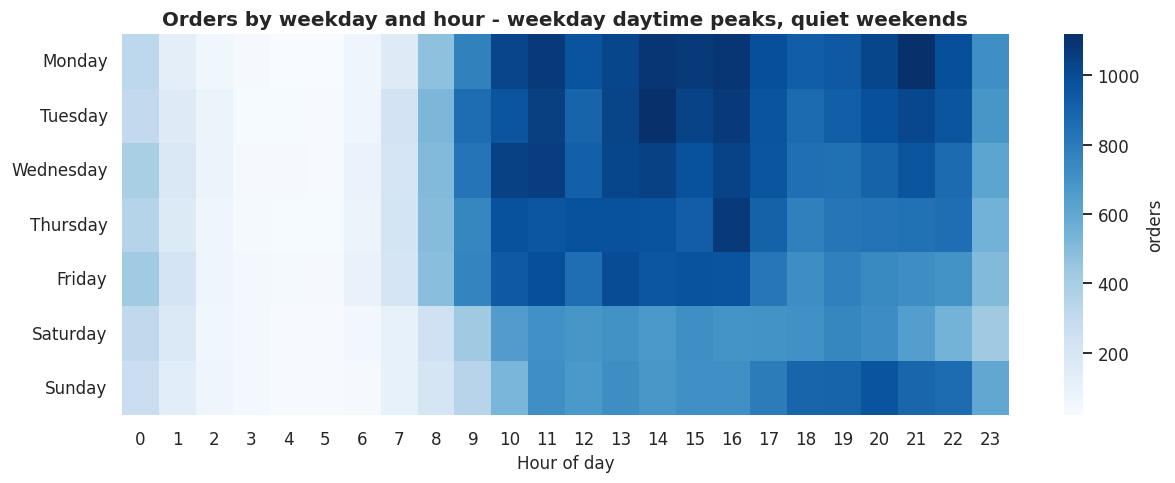

In [12]:
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heat = (dfw.pivot_table(index="purchase_weekday", columns="purchase_hour", values="order_id", aggfunc="count")
           .reindex(order_days))
fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(heat, cmap="Blues", ax=ax, cbar_kws={"label": "orders"})
ax.set_xlabel("Hour of day"); ax.set_ylabel("")
ax.set_title("Orders by weekday and hour - weekday daytime peaks, quiet weekends")
oa.save(fig, "02_weekday_hour_heatmap")
plt.show()

## Summary

* **Strong growth:** Jan-Aug 2018 orders were **+135 %** on the same months of 2017; the single biggest month was Black Friday (Nov 2017, 7,544 orders).
* **Concentrated revenue:** **18 of 74 categories** produce 80 % of item revenue (Pareto) - led by health & beauty, watches & gifts, bed/bath/table.
* **Payments:** credit card is **75 %** of orders (avg 3.6 instalments); *boleto* (bank slip) is 20 %. Instalments rise with basket size.
* **Geography:** customers are spread nationally, but **70 %** of orders ship from São Paulo sellers - so **64 %** of parcels cross state lines.
  This sets up the logistics question in the next notebook.

➡️ Next: [03 · Logistics & Delivery Performance](03_logistics_performance.ipynb)